
Error: id
          Df Sum Sq Mean Sq F value Pr(>F)
gender     1    0.2    0.20   0.005  0.946
Residuals 18  760.2   42.23               

Error: id:looks
             Df Sum Sq Mean Sq F value   Pr(>F)    
looks         2  23234   11617  328.25  < 2e-16 ***
gender:looks  2   4420    2210   62.45 1.97e-12 ***
Residuals    36   1274      35                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Error: id:personality
                   Df Sum Sq Mean Sq F value   Pr(>F)    
personality         2  20780   10390  423.73  < 2e-16 ***
gender:personality  2   3944    1972   80.43 5.23e-14 ***
Residuals          36    883      25                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Error: id:looks:personality
                         Df Sum Sq Mean Sq F value   Pr(>F)    
looks:personality         4   4055  1013.8   36.63  < 2e-16 ***
gender:looks:personality  4   2670   667.4   24.12 1.11e-12 ***
Residuals                


	Shapiro-Wilk normality test

data:  resids
W = 0.98248, p-value = 0.02329



--- Simple Main Effects for Gender 1 at High Looks ---


            Df Sum Sq Mean Sq F value   Pr(>F)    
personality  2   5662  2830.8   74.26 1.06e-11 ***
Residuals   27   1029    38.1                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


--- Simple Main Effects for Gender 2 at High Looks ---


            Df Sum Sq Mean Sq F value Pr(>F)
personality  2   42.5   21.23   0.445  0.645
Residuals   27 1286.9   47.66               

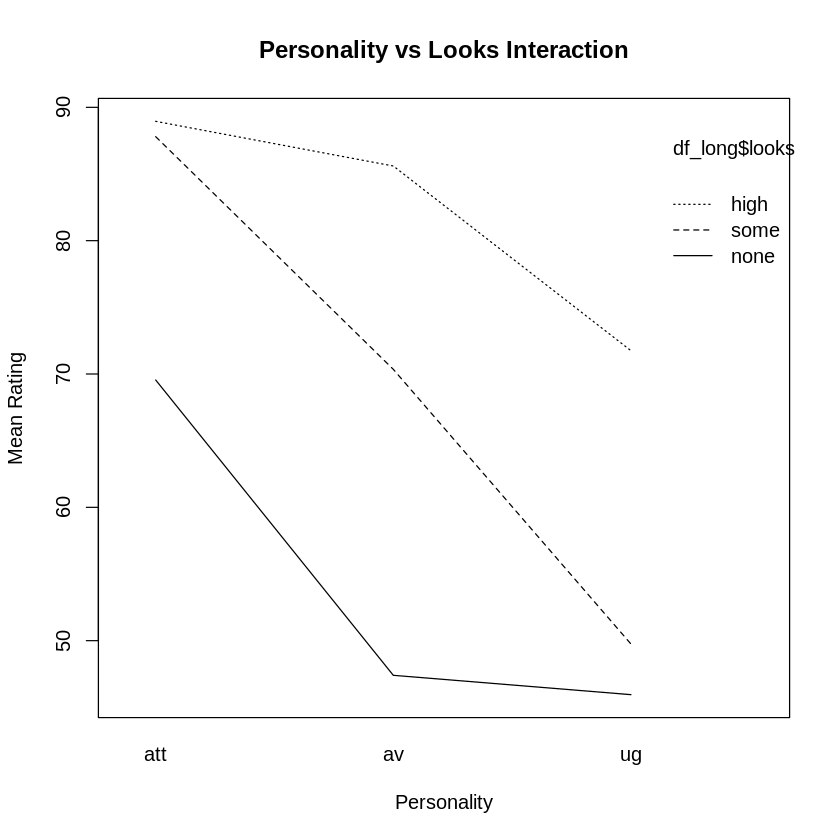

In [2]:
df_wide <- data.frame(
  gender = factor(rep(1:2, each = 10)),
  att_high = c(86,91,89,89,80,80,89,100,90,89, 89,84,99,86,89,80,82,97,95,95),
  av_high  = c(84,83,88,69,81,84,85,94,74,86, 91,90,100,89,87,81,92,69,92,93),
  ug_high  = c(67,53,48,58,57,51,61,56,54,63, 93,85,89,83,80,79,85,87,90,96),
  att_some = c(88,83,99,86,88,96,87,86,92,80, 88,95,80,86,83,86,81,95,98,79),
  av_some  = c(69,74,70,77,71,63,79,71,71,73, 65,70,79,74,74,59,66,72,64,66),
  ug_some  = c(50,48,48,40,50,42,44,54,58,49, 54,60,53,58,43,47,47,51,53,46),
  att_none = c(97,86,90,87,82,92,86,84,78,91, 55,50,51,52,58,51,50,45,54,52),
  av_none  = c(48,50,45,47,50,48,50,54,38,48, 48,44,48,48,50,47,45,48,53,39),
  ug_none  = c(47,46,48,53,45,43,45,47,45,39, 52,45,44,47,48,40,47,46,45,47)
)


df_long <- data.frame()
conditions <- colnames(df_wide)[-1]

for(i in 1:nrow(df_wide)) {
  for(cond in conditions) {
    parts <- strsplit(cond, "_")[[1]]
    row <- data.frame(
      id = factor(i),
      gender = df_wide$gender[i],
      personality = factor(parts[1]),
      looks = factor(parts[2]),
      rating = df_wide[i, cond]
    )
    df_long <- rbind(df_long, row)
  }
}


anova_model <- aov(rating ~ gender * looks * personality +
                   Error(id/(looks*personality)), data = df_long)

summary(anova_model)


resids <- residuals(lm(rating ~ gender * looks * personality, data = df_long))
shapiro.test(resids)


cat("\n--- Simple Main Effects for Gender 1 at High Looks ---\n")
g1_high <- subset(df_long, gender == 1 & looks == "high")
summary(aov(rating ~ personality, data = g1_high))

cat("\n--- Simple Main Effects for Gender 2 at High Looks ---\n")
g2_high <- subset(df_long, gender == 2 & looks == "high")
summary(aov(rating ~ personality, data = g2_high))


interaction.plot(x.factor = df_long$personality,
                 trace.factor = df_long$looks,
                 response = df_long$rating,
                 main = "Personality vs Looks Interaction",
                 xlab = "Personality", ylab = "Mean Rating")